# PortWatch: what is actually in this data

Comtrade is annual value by country. PortWatch is daily ship counts by chokepoint. Completely different shape, no key needed.

Goal here is to know what the columns mean, what the series looks like, and whether the data quality problems your brief lists are actually visible.

Kernel should be `.venv`.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

BASE = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services"
DAILY = f"{BASE}/Daily_Chokepoints_Data/FeatureServer/0"


def fetch_all(layer, where="1=1", out_fields="*", page=1000):
    """Page through an ArcGIS layer until it stops saying there is more."""
    rows, offset = [], 0
    while True:
        r = requests.get(
            f"{layer}/query",
            params={
                "where": where,
                "outFields": out_fields,
                "returnGeometry": "false",
                "resultOffset": offset,
                "resultRecordCount": page,
                "f": "json",
            },
            timeout=120,
        )
        r.raise_for_status()
        j = r.json()
        feats = j.get("features", [])
        rows += [f["attributes"] for f in feats]
        if not j.get("exceededTransferLimit") or not feats:
            break
        offset += len(feats)
    return pd.DataFrame(rows)


print("helper ready")

helper ready


## The 28 chokepoints

One row per chokepoint per day. First, what chokepoints exist and how much data each has.

In [2]:
ids = fetch_all(DAILY, out_fields="portid,portname,year")

summary = (
    ids.groupby(["portid", "portname"])
    .agg(days=("year", "size"), first_year=("year", "min"), last_year=("year", "max"))
    .reset_index()
    .sort_values("portname")
)
print(f"{len(summary)} chokepoints, {len(ids):,} total daily rows")
summary

28 chokepoints, 78,764 total daily rows


,portid,portname,days,first_year,last_year
22,chokepoint4,Bab el-Mandeb Strait,2813,2019,2026
17,chokepoint25,Balabac Strait,2813,2019,2026
18,chokepoint26,Bering Strait,2813,2019,2026
8,chokepoint17,Bohai Strait,2813,2019,2026
21,chokepoint3,Bosporus Strait,2813,2019,2026
25,chokepoint7,Cape of Good Hope,2813,2019,2026
27,chokepoint9,Dover Strait,2813,2019,2026
26,chokepoint8,Gibraltar Strait,2813,2019,2026
20,chokepoint28,Kerch Strait,2813,2019,2026
3,chokepoint12,Korea Strait,2813,2019,2026


## Pull the ones that matter to you

From the searoute spike, the chokepoints your baskets actually transit are Taiwan Strait, Korea Strait, Panama Canal, Tsugaru, Windward Passage, Malacca and Luzon. Hormuz is in here as a control: your routes never touch it, but it is the one in the news, and showing that contrast is part of the finding.

In [3]:
want = [
    "Taiwan Strait", "Korea Strait", "Panama Canal", "Tsugaru Strait",
    "Windward Passage", "Malacca Strait", "Luzon Strait", "Strait of Hormuz",
    "Suez Canal", "Bab el-Mandeb Strait",
]

picked = summary[summary["portname"].isin(want)]
print(f"matched {len(picked)} of {len(want)}")
print(set(want) - set(picked["portname"]))   # anything that did not match, fix the spelling
picked

matched 10 of 10
set()


,portid,portname,days,first_year,last_year
22,chokepoint4,Bab el-Mandeb Strait,2813,2019,2026
3,chokepoint12,Korea Strait,2813,2019,2026
5,chokepoint14,Luzon Strait,2813,2019,2026
23,chokepoint5,Malacca Strait,2813,2019,2026
11,chokepoint2,Panama Canal,2813,2019,2026
24,chokepoint6,Strait of Hormuz,2813,2019,2026
0,chokepoint1,Suez Canal,2813,2019,2026
2,chokepoint11,Taiwan Strait,2813,2019,2026
4,chokepoint13,Tsugaru Strait,2813,2019,2026
15,chokepoint23,Windward Passage,2813,2019,2026


In [4]:
frames = []
for pid, pname in picked[["portid", "portname"]].itertuples(index=False):
    f = fetch_all(DAILY, where=f"portid='{pid}'")
    print(f"{pname:22} {len(f):>6,} rows")
    frames.append(f)

pw = pd.concat(frames, ignore_index=True)
pw["day"] = pd.to_datetime(pw["date"], unit="ms")
print(f"\ntotal {len(pw):,} rows, {pw['day'].min().date()} to {pw['day'].max().date()}")

Bab el-Mandeb Strait    2,813 rows
Korea Strait            2,813 rows
Luzon Strait            2,813 rows
Malacca Strait          2,813 rows
Panama Canal            2,813 rows
Strait of Hormuz        2,813 rows
Suez Canal              2,813 rows
Taiwan Strait           2,813 rows
Tsugaru Strait          2,813 rows
Windward Passage        2,813 rows

total 28,130 rows, 2019-01-01 to 2026-09-13


## What the columns mean

Two families, and the difference matters.

- `n_*` is a **count of ships** that transited that day. `n_total` is all of them, `n_container` is container ships only, and so on.
- `capacity_*` is **estimated cargo capacity** of those ships, in tonnes.

The vessel type breakdown is the important part for you. Chips and magnets travel in containers. Oil travels in tankers. Filtering to `n_container` makes every number about your goods instead of about crude, and it is a one column change.

In [5]:
pw.describe().T

,count,mean,min,25%,50%,75%,max,std
year,28130.0,2022.364024,2019.0,2020.0,2022.0,2024.0,2026.0,2.227046
month,28130.0,6.361536,1.0,3.0,6.0,9.0,12.0,3.407947
day,28130,2022-11-07 00:00:00,2019-01-01 00:00:00,2020-12-04 00:00:00,2022-11-07 00:00:00,2024-10-10 00:00:00,2026-09-13 00:00:00,NaN
n_container,28130.0,26.668894,0.0,8.0,13.0,47.0,172.0,27.312178
n_dry_bulk,28130.0,25.387487,0.0,9.0,17.0,40.0,148.0,21.684893
n_general_cargo,28130.0,13.412407,0.0,3.0,6.0,15.0,149.0,17.802387
n_roro,28130.0,3.66438,0.0,1.0,3.0,5.0,22.0,3.204704
n_tanker,28130.0,32.734092,0.0,12.0,22.0,56.0,148.0,25.765379
n_cargo,28130.0,69.133167,0.0,22.0,39.0,120.0,344.0,63.450975
n_total,28130.0,101.867259,0.0,36.0,64.0,188.0,472.0,85.303625


In [6]:
# what kind of traffic is each chokepoint, really?
mix = pw.groupby("portname")[["n_container", "n_tanker", "n_dry_bulk", "n_general_cargo", "n_roro", "n_total"]].mean()
share = mix[["n_container", "n_tanker", "n_dry_bulk", "n_general_cargo", "n_roro"]].div(mix["n_total"], axis=0)
(share * 100).round(1).sort_values("n_container", ascending=False)

,n_container,n_tanker,n_dry_bulk,n_general_cargo,n_roro
portname,,,,,
Windward Passage,47.6,13.1,11.8,16.8,10.7
Taiwan Strait,35.3,22.9,26.9,12.3,2.6
Suez Canal,27.3,32.9,26.3,9.7,3.8
Bab el-Mandeb Strait,25.5,33.6,27.2,9.1,4.6
Malacca Strait,25.4,37.9,25.8,7.7,3.2
Korea Strait,24.8,27.6,18.1,25.4,4.0
Panama Canal,24.1,40.3,21.1,7.6,6.9
Tsugaru Strait,23.2,26.6,29.0,16.8,4.4
Strait of Hormuz,16.5,59.8,16.5,4.6,2.6


Read that table carefully. If Hormuz is overwhelmingly tanker and Taiwan Strait is heavily container, that is a quantified reason why Hormuz is not your risk, independent of the routing analysis. Two separate lines of evidence pointing the same way is much stronger than one.

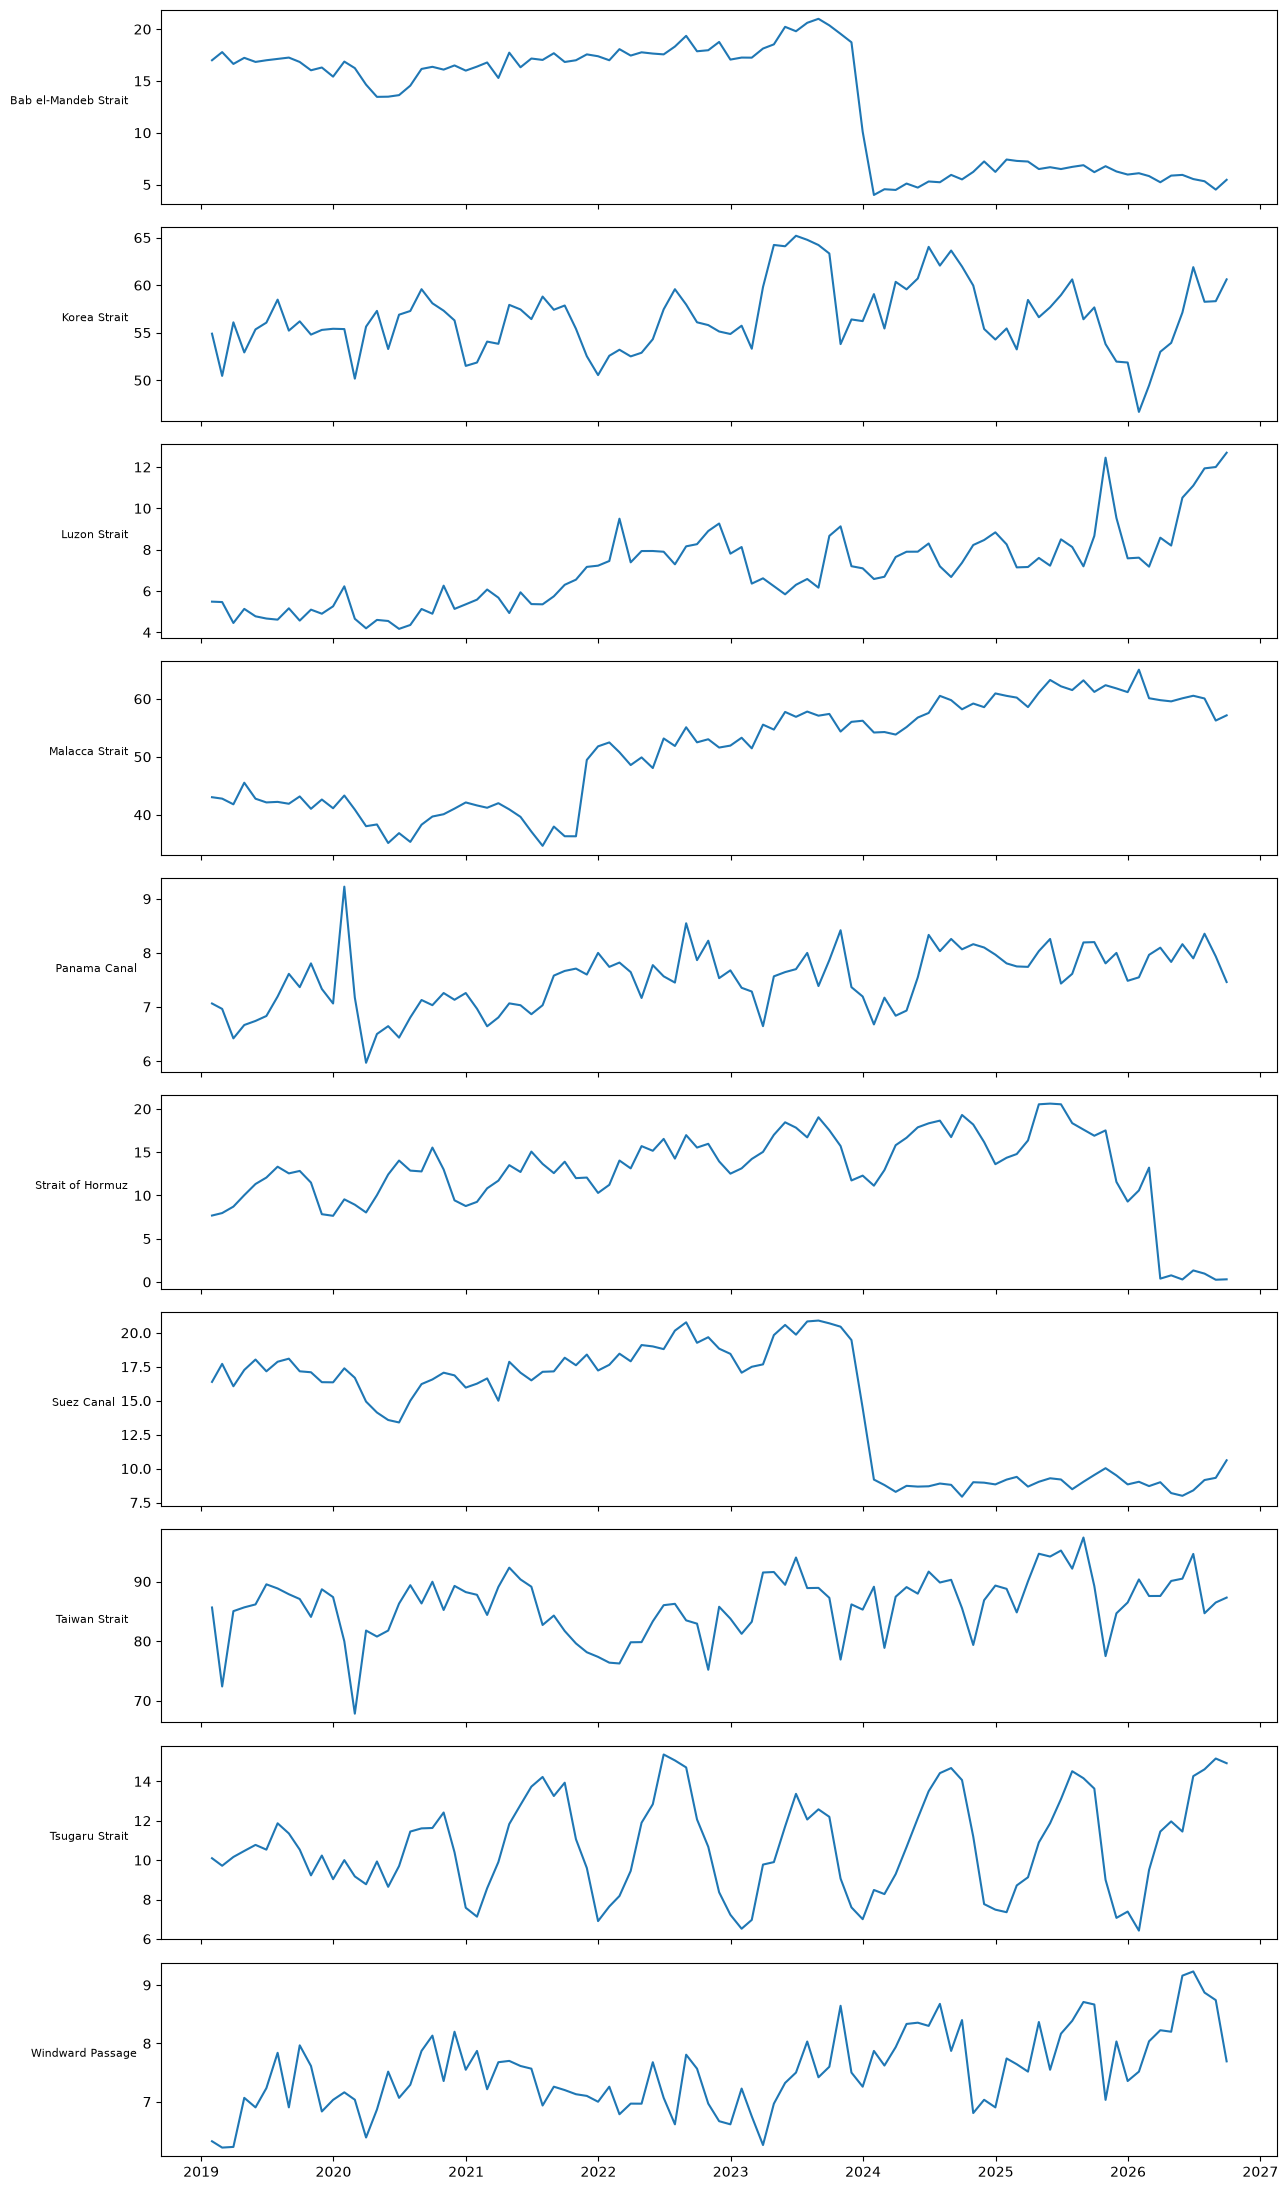

In [7]:
# container traffic over time, monthly average of daily counts
m = (
    pw.set_index("day")
    .groupby("portname")["n_container"]
    .resample("ME").mean()
    .unstack(0)
)

fig, axes = plt.subplots(len(m.columns), 1, figsize=(13, 2.2 * len(m.columns)), sharex=True)
for ax, col in zip(axes, m.columns):
    ax.plot(m.index, m[col])
    ax.set_ylabel(col, rotation=0, ha="right", fontsize=8)
plt.tight_layout()

## Now go looking for the things your brief warns about

### 1. The 2021 receiver coverage expansion

The brief says a sensor upgrade caused a permanent step change at Malacca that is not real growth. A step looks like a cliff that never comes back down. Real demand growth ramps.

2020 mean: 161.2
2022 mean: 207.1


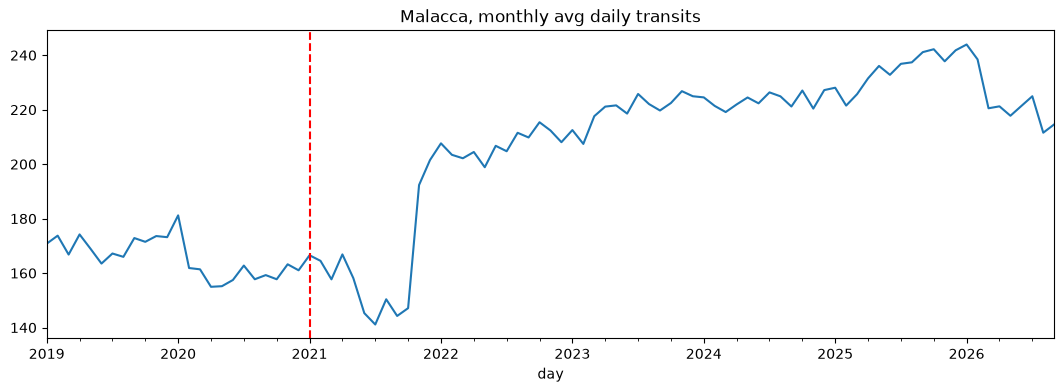

In [8]:
mal = pw[pw["portname"] == "Malacca Strait"].set_index("day")["n_total"].resample("ME").mean()
ax = mal.plot(figsize=(13, 4), title="Malacca, monthly avg daily transits")
ax.axvline(pd.Timestamp("2021-01-01"), color="red", ls="--")

print("2020 mean:", round(mal["2020"].mean(), 1))
print("2022 mean:", round(mal["2022"].mean(), 1))

### 2. The blackout dates

Missing, zero, or normal? Whichever it is dictates how the dbt test is written.

In [9]:
for d in ["2022-05-12", "2023-02-14", "2024-01-09"]:
    hit = pw[pw["day"] == pd.Timestamp(d)]
    print(f"{d}: {len(hit)} rows, n_total values: {sorted(hit['n_total'].unique())[:6]}")

2022-05-12: 10 rows, n_total values: [np.int64(8), np.int64(29), np.int64(60), np.int64(67), np.int64(76), np.int64(77)]
2023-02-14: 10 rows, n_total values: [np.int64(16), np.int64(32), np.int64(36), np.int64(68), np.int64(69), np.int64(76)]
2024-01-09: 10 rows, n_total values: [np.int64(10), np.int64(17), np.int64(29), np.int64(49), np.int64(53), np.int64(54)]


### 3. Panama, 2023 to 2024

Drought cut the canal's daily transit slots. This is your historical event study candidate, and it should be visible without any statistics.

<Axes: title={'center': 'Panama Canal, monthly avg daily transits'}, xlabel='day'>

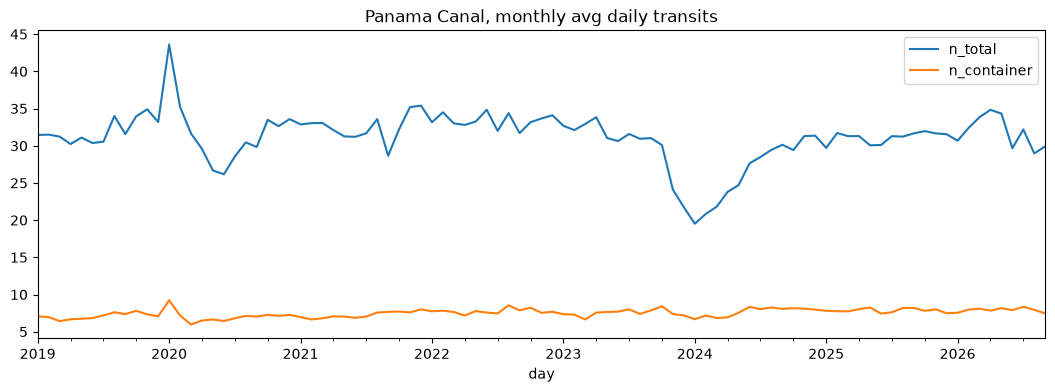

In [10]:
pan = pw[pw["portname"] == "Panama Canal"].set_index("day")[["n_total", "n_container"]].resample("ME").mean()
pan.plot(figsize=(13, 4), title="Panama Canal, monthly avg daily transits")

### 4. Hormuz, 2026

Closed since late February. If PortWatch shows the collapse, you have a live natural experiment in your own data. Note the container share from the mix table above before drawing conclusions about your baskets.

2025 mean: 85.5
2026 mean: 20.9
last 30 days mean: 103.9


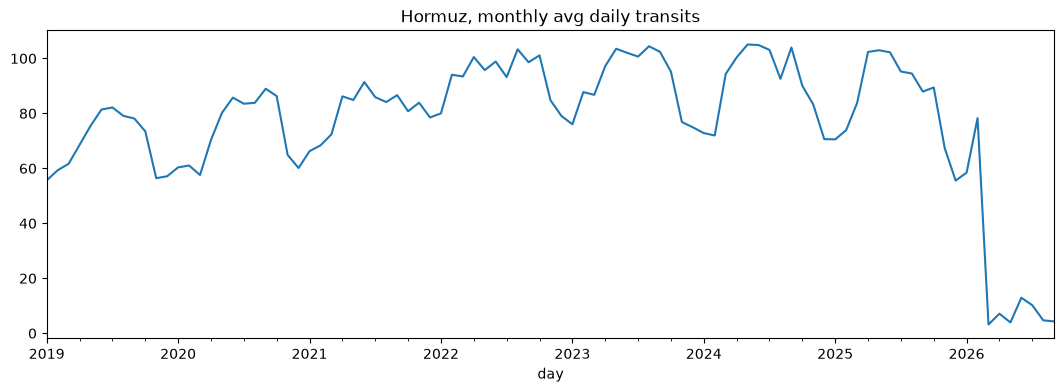

In [11]:
hz = pw[pw["portname"] == "Strait of Hormuz"].set_index("day")["n_total"]
hz.resample("ME").mean().plot(figsize=(13, 4), title="Hormuz, monthly avg daily transits")

print("2025 mean:", round(hz["2025"].mean(), 1))
print("2026 mean:", round(hz["2026"].mean(), 1))
print("last 30 days mean:", round(hz.tail(30).mean(), 1))

### 5. Did anywhere absorb the redirected traffic?

If Gulf traffic rerouted, some other chokepoint should show a rise in the same window. Compare 2026 against each chokepoint's own 2025 baseline.

In [12]:
base = pw[pw["day"].dt.year == 2025].groupby("portname")["n_total"].mean()
now = pw[pw["day"] >= "2026-03-01"].groupby("portname")["n_total"].mean()

cmp = pd.DataFrame({"2025_baseline": base, "since_mar_2026": now})
cmp["pct_change"] = ((cmp["since_mar_2026"] / cmp["2025_baseline"] - 1) * 100).round(1)
cmp.sort_values("pct_change", ascending=False)

,2025_baseline,since_mar_2026,pct_change
portname,,,
Luzon Strait,66.391781,81.208122,22.3
Tsugaru Strait,45.695890,51.558376,12.8
Suez Canal,38.547945,40.883249,6.1
Windward Passage,15.676712,16.395939,4.6
Panama Canal,31.123288,32.147208,3.3
Bab el-Mandeb Strait,33.473973,33.796954,1.0
Taiwan Strait,238.835616,238.335025,-0.2
Korea Strait,219.367123,212.766497,-3.0
Malacca Strait,234.487671,219.218274,-6.5


## Gaps and quirks

Missing days are not the same as zero days. Check whether the series is actually continuous before any dbt test assumes it is.

In [13]:
for name, g in pw.groupby("portname"):
    full = pd.date_range(g["day"].min(), g["day"].max(), freq="D")
    missing = len(full) - g["day"].nunique()
    zeros = int((g["n_total"] == 0).sum())
    print(f"{name:22} span {len(full):>5} days | missing {missing:>4} | zero-transit days {zeros:>4}")

Bab el-Mandeb Strait   span  2813 days | missing    0 | zero-transit days    0
Korea Strait           span  2813 days | missing    0 | zero-transit days    0
Luzon Strait           span  2813 days | missing    0 | zero-transit days    2
Malacca Strait         span  2813 days | missing    0 | zero-transit days    0
Panama Canal           span  2813 days | missing    0 | zero-transit days    0
Strait of Hormuz       span  2813 days | missing    0 | zero-transit days   12
Suez Canal             span  2813 days | missing    0 | zero-transit days    0
Taiwan Strait          span  2813 days | missing    0 | zero-transit days    0
Tsugaru Strait         span  2813 days | missing    0 | zero-transit days    0
Windward Passage       span  2813 days | missing    0 | zero-transit days    1


## What you found

Fill this in. It becomes the data quality section of the FRD and the dbt test list.

- Container share at the chokepoints my goods transit: ...
- Container share at Hormuz: ...
- 2021 Malacca step change: visible / not visible, size ...
- Blackout dates appear as: missing rows / zeros / normal values
- Panama drought visible: yes / no, roughly ...% drop, dates ...
- Hormuz 2026: 2025 baseline ..., current ...
- Anywhere absorbing redirected traffic: ...
- Series gaps worth a test: ...
- Still confusing: ...